# Student Placement Prediction Using Machine Learning

## Objective

The objective of this project is to develop a machine learning model that predicts whether a student will be placed based on their CGPA and IQ score.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [18]:
import pandas as pd
data = pd.read_csv("/content/placement-dataset.csv")

In [20]:
data.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [21]:
data.shape

(100, 4)

In [22]:
data.columns

Index(['Unnamed: 0', 'cgpa', 'iq', 'placement'], dtype='object')

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [28]:
data = data.drop("Unnamed: 0", axis=1, errors='ignore')

In [30]:
data.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [31]:
print(data.isnull().sum())

cgpa         0
iq           0
placement    0
dtype: int64


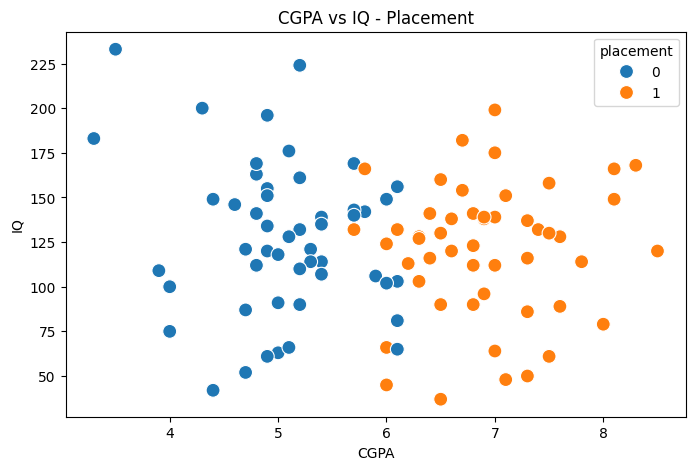

In [34]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=data,x="cgpa",y="iq",hue="placement",s=100)

plt.title("CGPA vs IQ - Placement")
plt.xlabel("CGPA")
plt.ylabel("IQ")

plt.show()

In [33]:
X = data[["cgpa", "iq"]]
y = data["placement"]

print("Input features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input features:
   cgpa     iq
0   6.8  123.0
1   5.9  106.0
2   5.3  121.0
3   7.4  132.0
4   5.8  142.0

Target:
0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64


In [36]:
X = data[['cgpa', 'iq']]
y = data['placement']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80, 2)
Testing data: (20, 2)


In [38]:
model = LogisticRegression()

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [39]:
y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[1 1 1 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 1]


In [40]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.85
Accuracy Percentage: 85.0 %


In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.89      0.80      0.84        10

    accuracy                           0.85        20
   macro avg       0.85      0.85      0.85        20
weighted avg       0.85      0.85      0.85        20



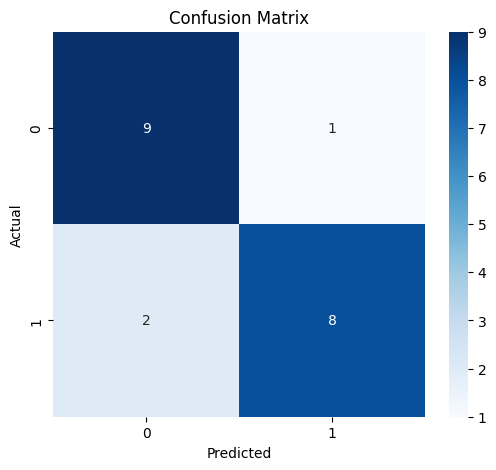

In [42]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [43]:
cgpa = 8.0
iq = 120

new_student = pd.DataFrame({
    "cgpa": [cgpa],
    "iq": [iq]
})

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Prediction: Student is likely to be PLACED 🎉")
else:
    print("Prediction: Student is likely to be NOT PLACED.")

Prediction: Student is likely to be PLACED 🎉


In [44]:
probability = model.predict_proba(new_student)

print("Probability of NOT PLACED:", round(probability[0][0] * 100, 2), "%")
print("Probability of PLACED:", round(probability[0][1] * 100, 2), "%")

Probability of NOT PLACED: 0.26 %
Probability of PLACED: 99.74 %
